In [1]:
# Chạy ô này để cài đặt các thư viện bị thiếu trong môi trường Jupyter của bạn
!pip install yfinance pandas-ta matplotlib seaborn
%pip install yfinance pandas-ta


Note: you may need to restart the kernel to use updated packages.


# Khám phá Dữ liệu và Tính toán Đặc trưng (EDA)

Đây là notebook EDA được cập nhật đồng bộ với pipeline dữ liệu mới nhất (sử dụng 

etch_and_prepare_data).

In [2]:

import sys
import os
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Thêm thư mục gốc để nạp module src
sys.path.append(os.path.abspath(os.path.join('..')))
from src.data_loader import fetch_and_prepare_data

# 1. Tải và xử lý dữ liệu với mã VNM.VN (Vinamilk - Sàn HoSE)
df = fetch_and_prepare_data('VNM.VN', start_date='2015-01-01', end_date='2026-05-20')

print('\n✅ Đã nạp và tính toán đặc trưng thành công từ Pipeline chính thức!')
display(df.tail())

Đang kết nối Yahoo Finance để tải dữ liệu mã: VNM.VN...


[*********************100%***********************]  1 of 1 completed

Tải dữ liệu trực tuyến thành công!
Khởi động Feature Engineering: Tính toán các chỉ báo kỹ thuật...
💾 Đã lưu dữ liệu đặc trưng sạch vào: data/VNM.VN_processed.csv
📊 Hệ thống sẵn sàng với 669 phiên giao dịch hoàn chỉnh.


✅ Đã nạp và tính toán đặc trưng thành công từ Pipeline chính thức!


,date,close,high,low,open,volume,rsi_14,MACD_12_26_9,volatility_20,close_lag1,volume_change,intraday_return,target_return
664,2026-05-12,60100.0,60700.0,59900.0,60600.0,4223867,38.825132,-397.124008,0.007031,60600.0,0.087635,-0.008251,0.000000
665,2026-05-13,59300.0,60100.0,58700.0,60100.0,8549520,34.311712,-505.605232,0.006199,60100.0,1.024098,-0.013311,0.000000
666,2026-05-14,60100.0,60100.0,59300.0,59300.0,3123761,41.620388,-521.018097,0.007181,59300.0,-0.634627,0.013491,0.000000
667,2026-05-15,59800.0,60300.0,59800.0,60100.0,2016323,39.830671,-551.087799,0.006779,60100.0,-0.354521,-0.004992,-0.005017
668,2026-05-18,60500.0,60700.0,59500.0,59500.0,4907974,45.698184,-512.526024,0.007027,59800.0,1.434121,0.016807,0.000000


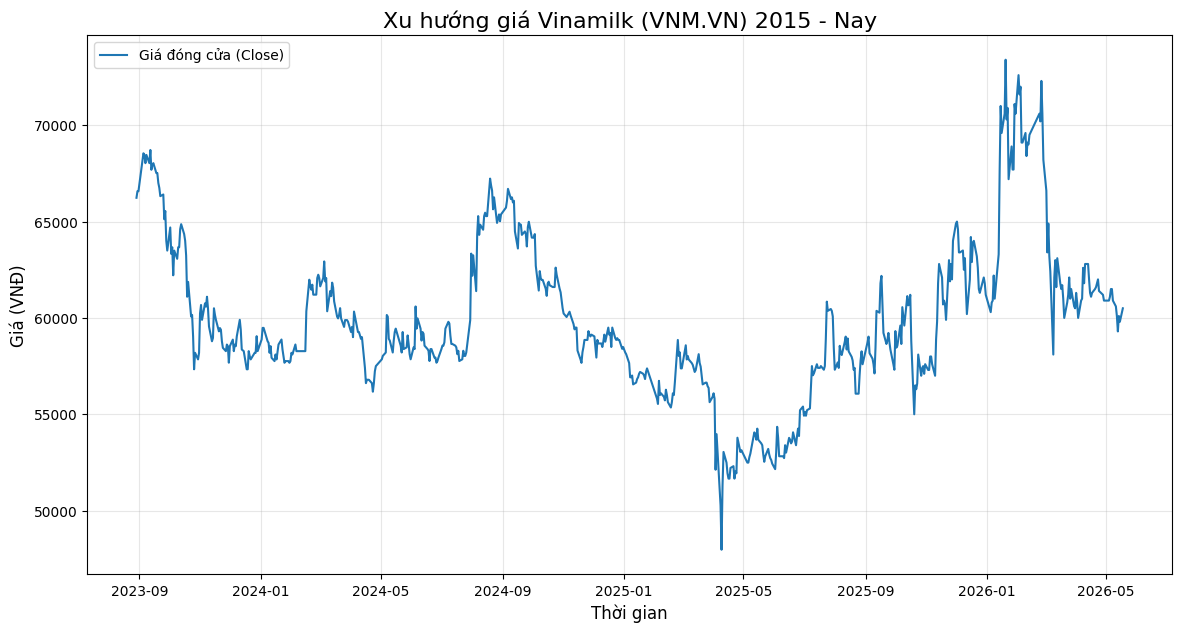

In [3]:
# 2. Trực quan hóa giá đóng cửa
plt.figure(figsize=(14, 7))
plt.plot(df['date'], df['close'], color='#1f77b4', linewidth=1.5, label='Giá đóng cửa (Close)')
plt.title('Xu hướng giá Vinamilk (VNM.VN) 2015 - Nay', fontsize=16)
plt.xlabel('Thời gian', fontsize=12)
plt.ylabel('Giá (VNĐ)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

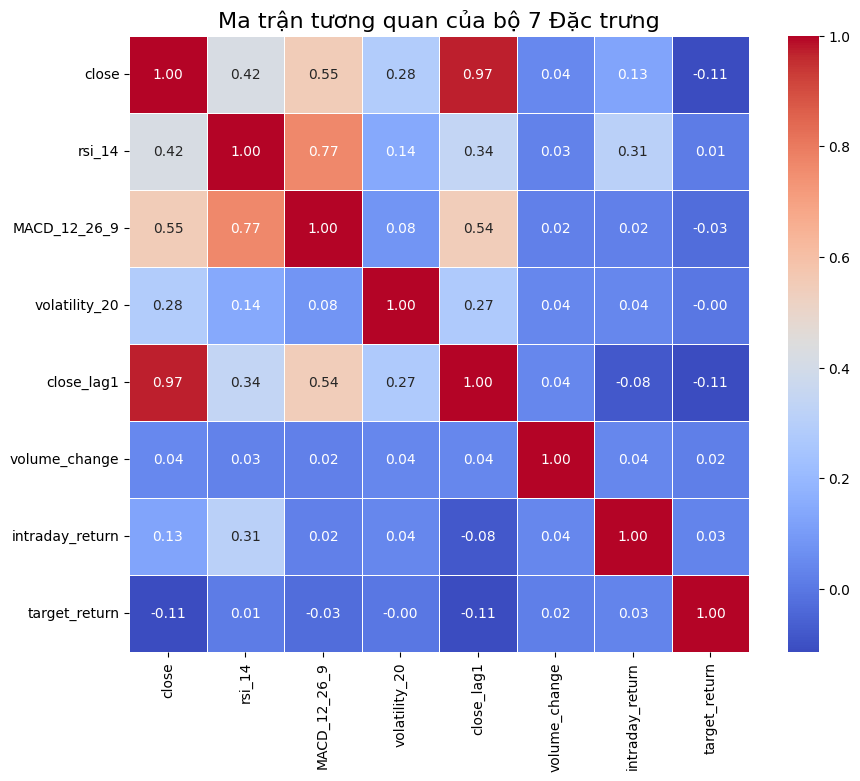

In [4]:
# 3. Phân tích Tương quan (Correlation) của 7 Features và Target Return
features = ['close', 'rsi_14', 'MACD_12_26_9', 'volatility_20', 'close_lag1', 'volume_change', 'intraday_return', 'target_return']
corr_matrix = df[features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Ma trận tương quan của bộ 7 Đặc trưng', fontsize=16)
plt.show()

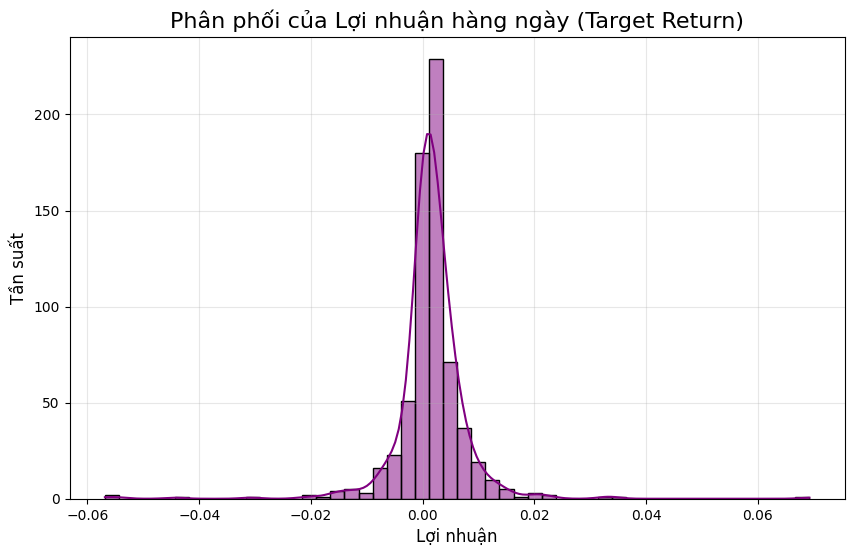

In [5]:
# 4. Phân tích phân phối của Lợi nhuận mục tiêu (Target Return)
plt.figure(figsize=(10, 6))
sns.histplot(df['target_return'].dropna(), bins=50, kde=True, color='purple')
plt.title('Phân phối của Lợi nhuận hàng ngày (Target Return)', fontsize=16)
plt.xlabel('Lợi nhuận', fontsize=12)
plt.ylabel('Tần suất', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

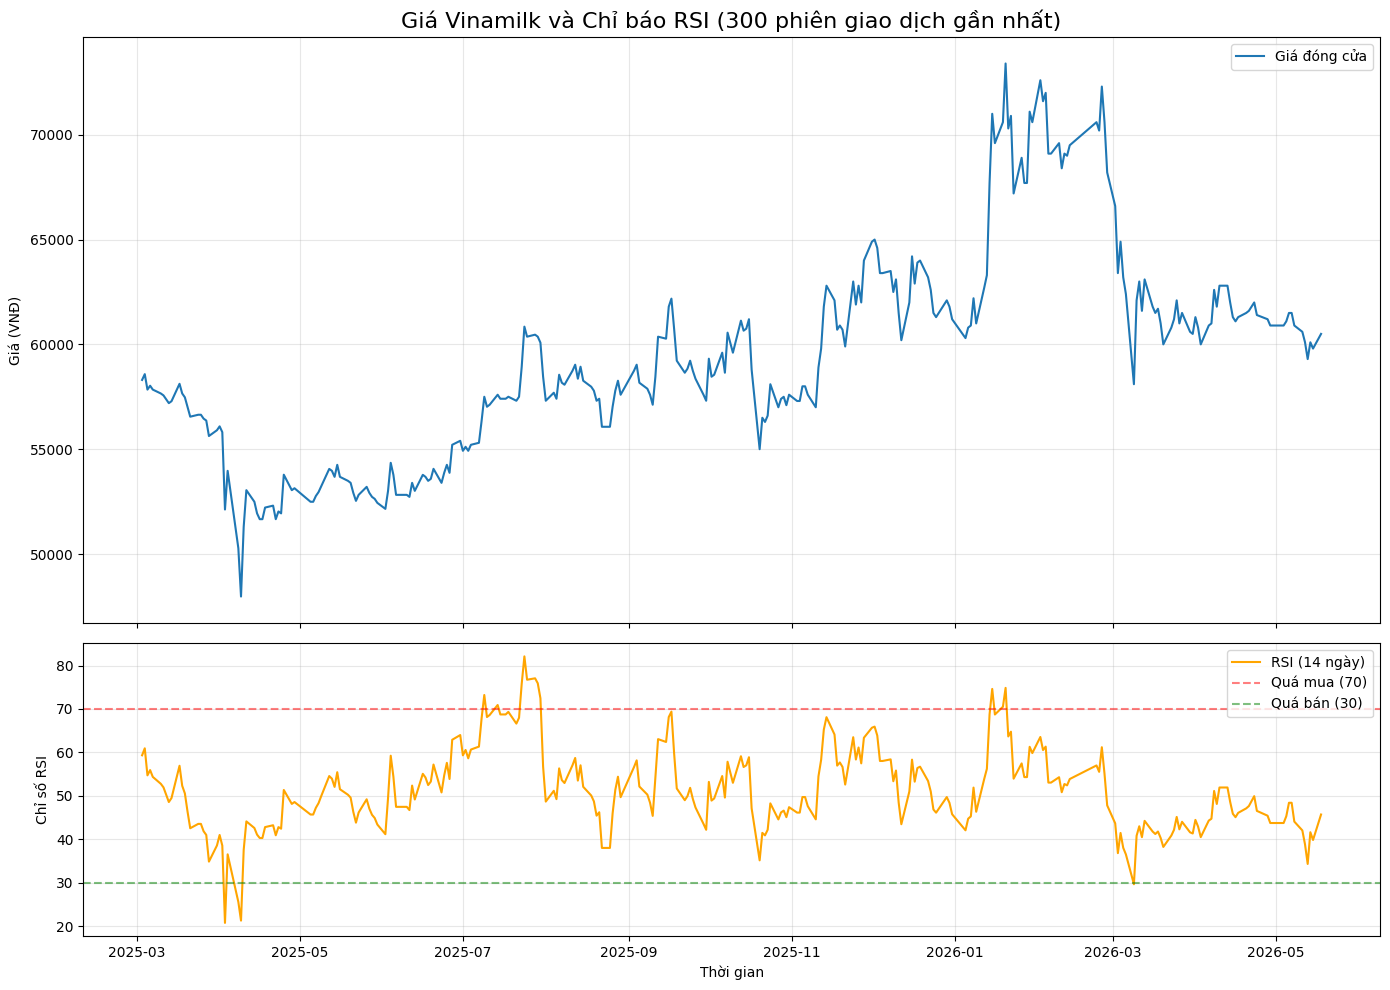

In [6]:
# 5. Trực quan hóa Chỉ báo RSI và Vùng quá mua/quá bán (300 phiên gần nhất)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={'height_ratios': [2, 1]}, sharex=True)

# Đồ thị Giá
ax1.plot(df['date'][-300:], df['close'][-300:], color='#1f77b4', label='Giá đóng cửa', linewidth=1.5)
ax1.set_title('Giá Vinamilk và Chỉ báo RSI (300 phiên giao dịch gần nhất)', fontsize=16)
ax1.set_ylabel('Giá (VNĐ)')
ax1.grid(True, alpha=0.3)
ax1.legend()

# Đồ thị RSI
ax2.plot(df['date'][-300:], df['rsi_14'][-300:], color='orange', label='RSI (14 ngày)')
ax2.axhline(70, color='red', linestyle='--', alpha=0.5, label='Quá mua (70)')
ax2.axhline(30, color='green', linestyle='--', alpha=0.5, label='Quá bán (30)')
ax2.set_ylabel('Chỉ số RSI')
ax2.set_xlabel('Thời gian')
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

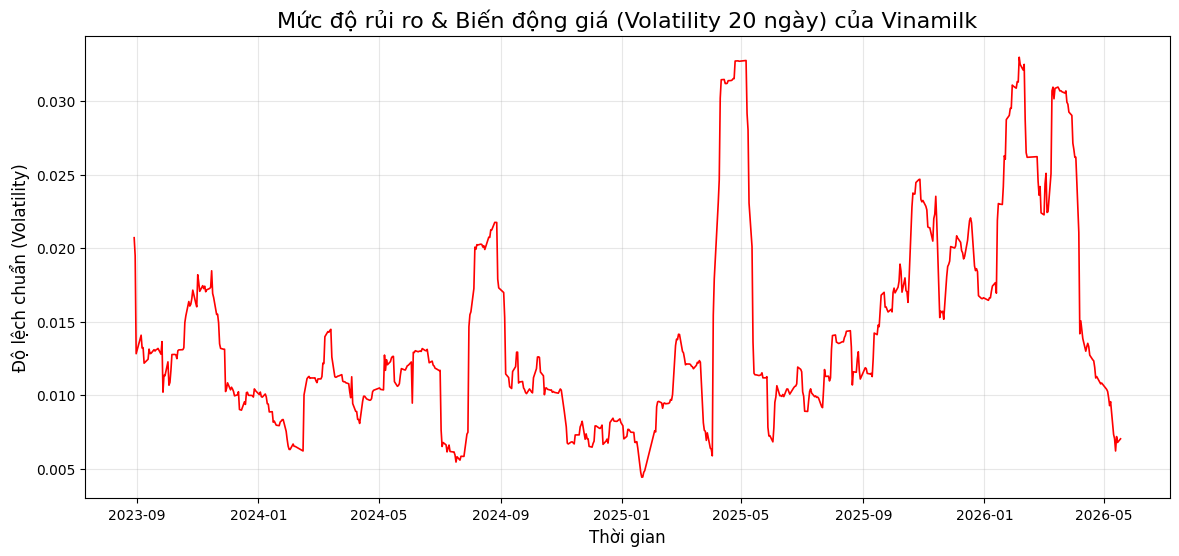

In [7]:
# 6. Biến động giá (Volatility) qua các năm
plt.figure(figsize=(14, 6))
plt.plot(df['date'], df['volatility_20'], color='red', linewidth=1.2)
plt.title('Mức độ rủi ro & Biến động giá (Volatility 20 ngày) của Vinamilk', fontsize=16)
plt.xlabel('Thời gian', fontsize=12)
plt.ylabel('Độ lệch chuẩn (Volatility)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()